<a href="https://colab.research.google.com/github/aaryachauhan123/AI-ML-Learning/blob/main/Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import necessary libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


importing data set

In [ ]:
data = pd.read_csv('/content/agriculture sustainability')
#check for mission values
print(data.isnull().sum)
#handle missing values with mean()
data.fillna(data.mean(), inplace=True)

print(data.head())

<bound method DataFrame.sum of      soil_health  crop_yield  water_usage  carbon_footprint  fertilizer_use  \
0          False       False        False             False           False   
1          False       False        False             False           False   
2          False       False        False             False           False   
3          False       False        False             False           False   
4          False       False        False             False           False   
..           ...         ...          ...               ...             ...   
195        False       False        False             False           False   
196        False       False        False             False           False   
197        False       False        False             False           False   
198        False       False        False             False           False   
199        False       False        False             False           False   

     sustainability 

In [ ]:
data.shape

(200, 6)

In [ ]:
#defining features and target variable
X = data[['soil_health', 'crop_yield', 'water_usage', 'carbon_footprint', 'fertilizer_use']] #input feataures
y = data[['sustainability']]  #target variable

spliting of data in to training and testing

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#set number of neighbours
k=5
model = RandomForestClassifier(max_depth=3,random_state=36373)# ana andar na parameters na nakhi to chale accuracy par farak padse
model.fit(X_train,y_train)  #training of model starts here
print(model.n_estimators) #plannimg how many tree to generate
print(len(model.estimators_)) #actually howany generated

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


100
100


In [ ]:
#we are prdicting values of target variable using X_test and storing it in y_pred variable
y_pred = model.predict(X_test)

In [ ]:
# Accuracy
#we are comparing y test with y predict to get the accuracy of predicted data.
accuracy = accuracy_score(y_test,y_pred)
print("accuracy :",accuracy)

accuracy : 0.9


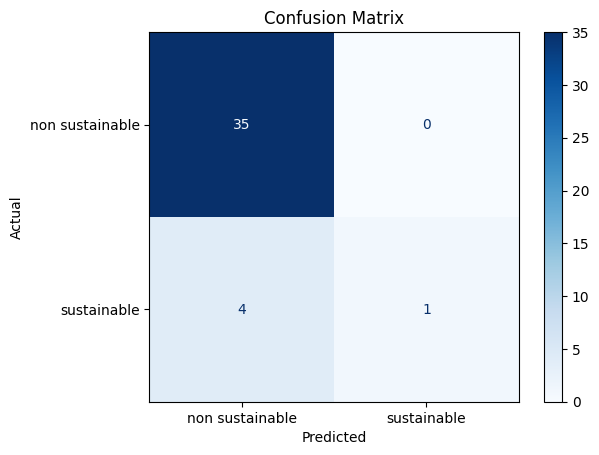

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap='Greens',
            xticklabels = ['Non Adoption', 'Adoption'],
            yticklabels = ['Non Adoption', 'Adoption'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
print("Confusion Matrix:")

In [ ]:
# Generate the classification report
# The classification report shows the precision, recall, f1-score, and support for each class.
# 'non adoption' corresponds to the target value 0, and 'adoption' corresponds to the target value 1.
report = classification_report(y_test, y_pred, target_names=['non adoption', 'adoption'])
print(report)

              precision    recall  f1-score   support

non adoption       0.89      0.94      0.91        17
    adoption       0.50      0.33      0.40         3

    accuracy                           0.85        20
   macro avg       0.69      0.64      0.66        20
weighted avg       0.83      0.85      0.84        20



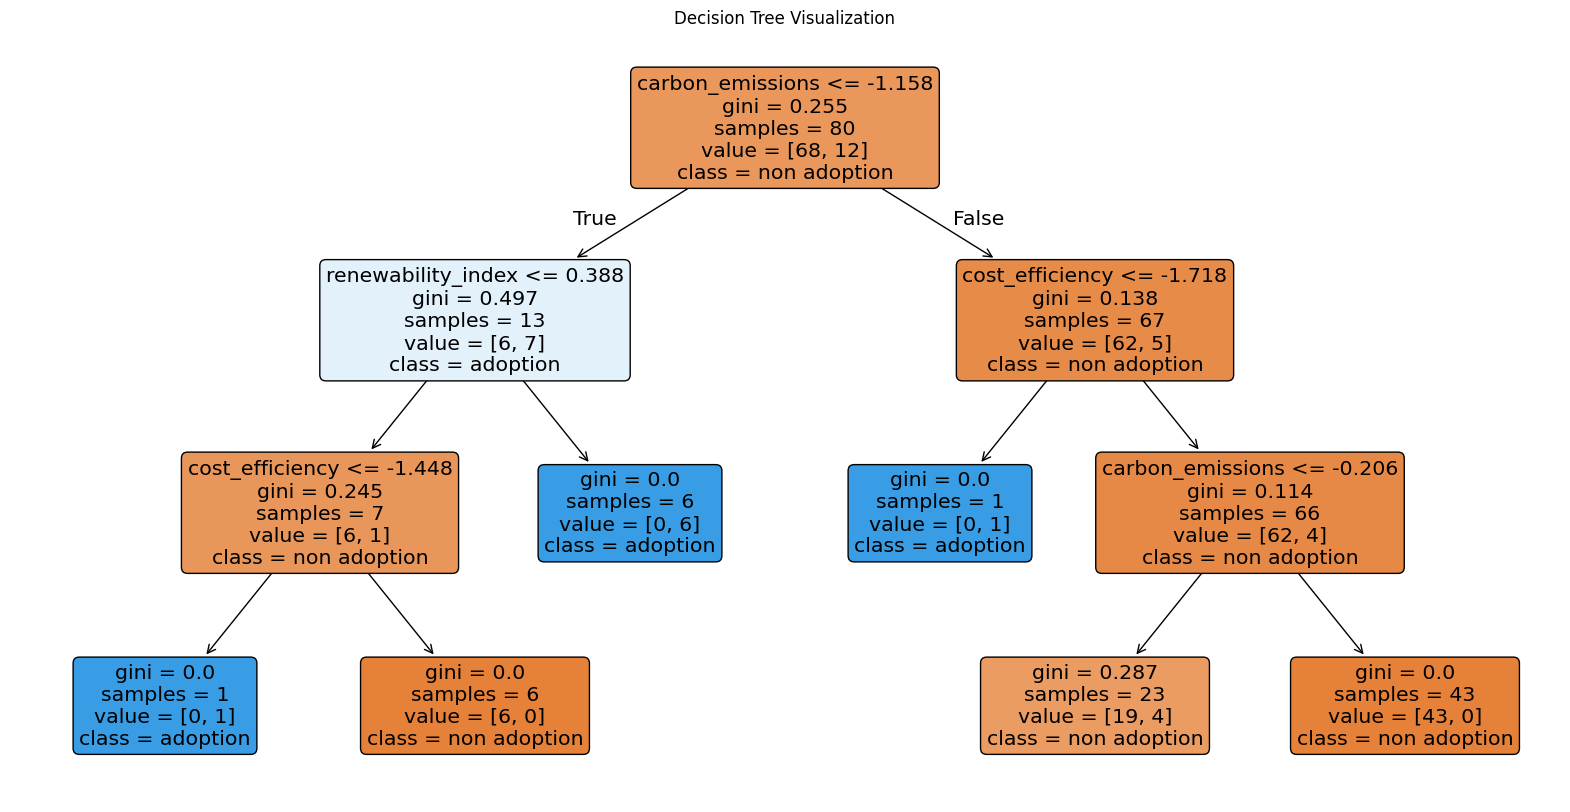

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=['non adoption', 'adoption'], filled=True, rounded=True)
plt.title('Decision Tree Visualization')
plt.show()